In [13]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
data = {}

for h in range(5, 16):
    data[h] = {}

    for L in range(5, 7):
        data[h][L] = pd.read_csv(f"spectra_h{h}_L{L}.dat",sep="\t")

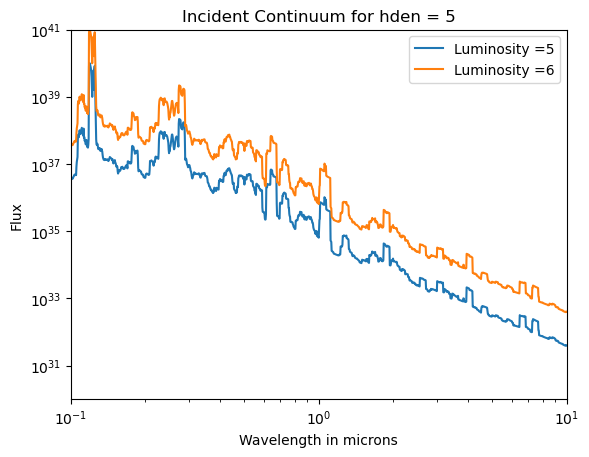

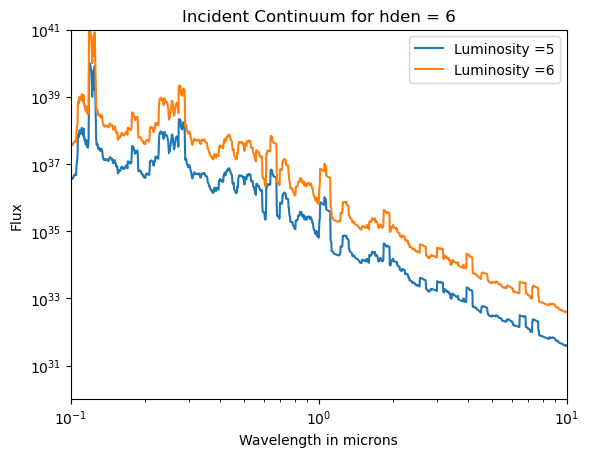

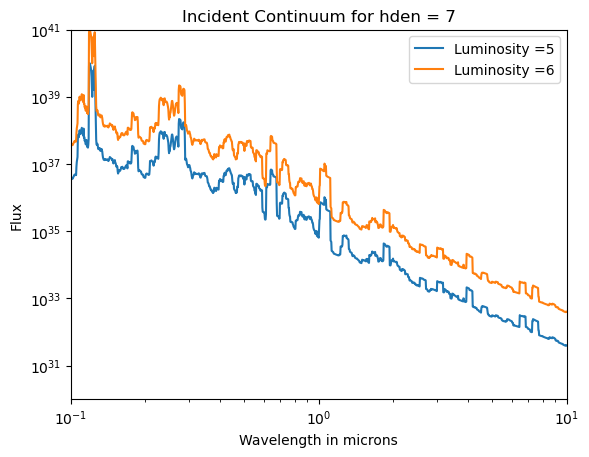

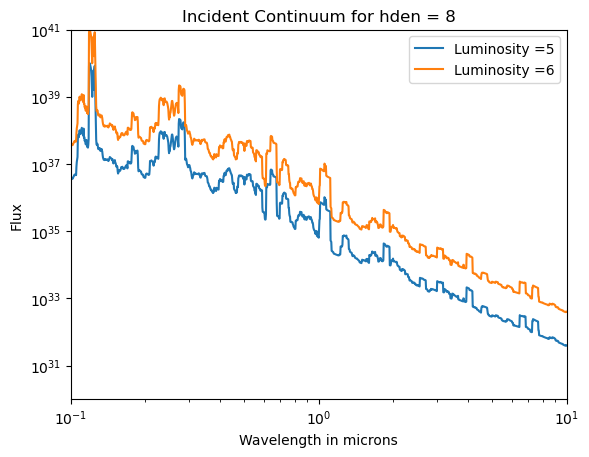

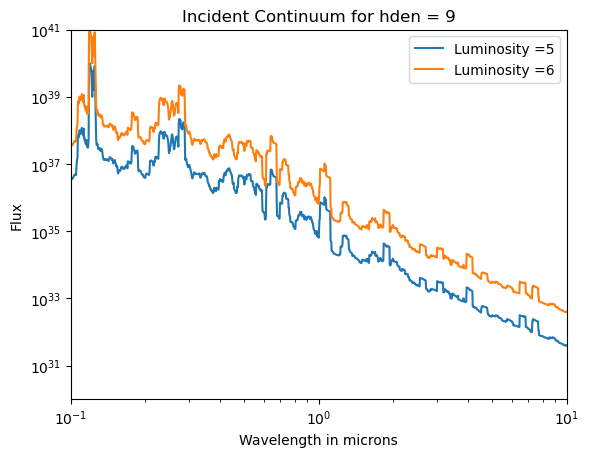

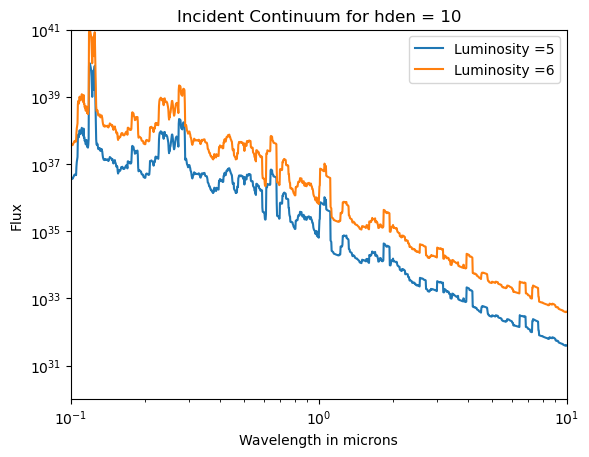

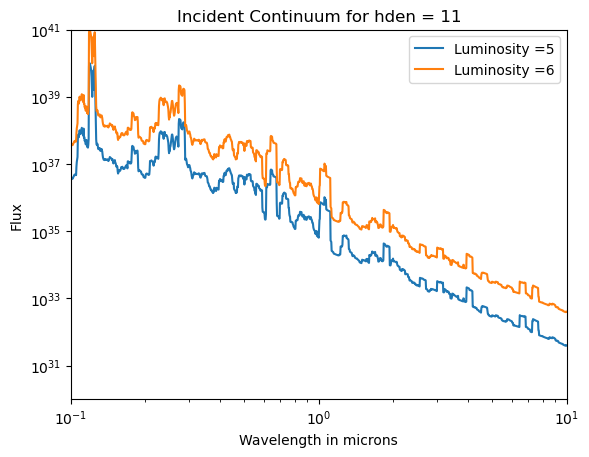

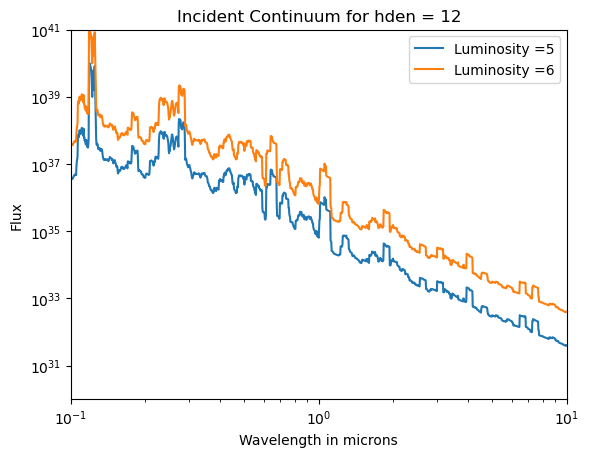

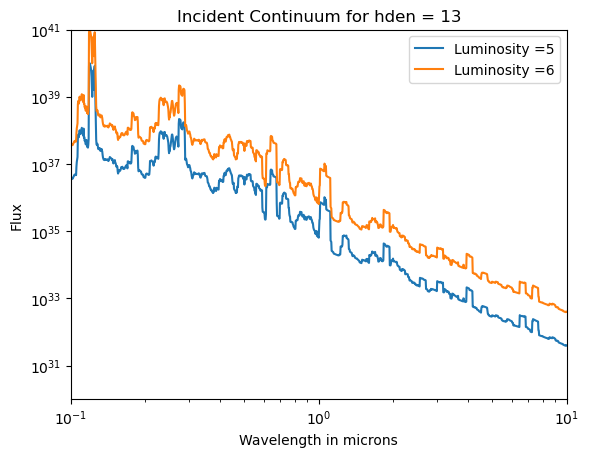

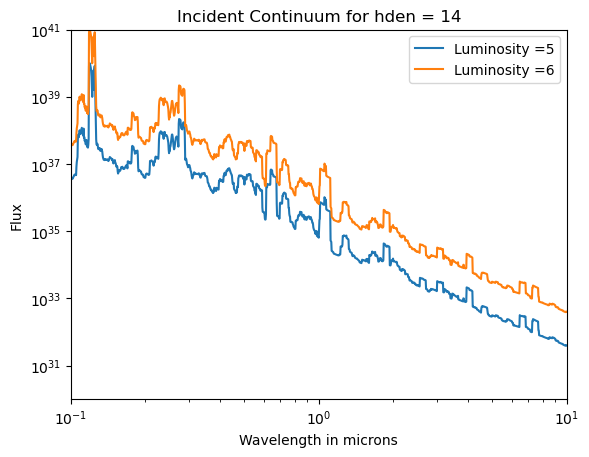

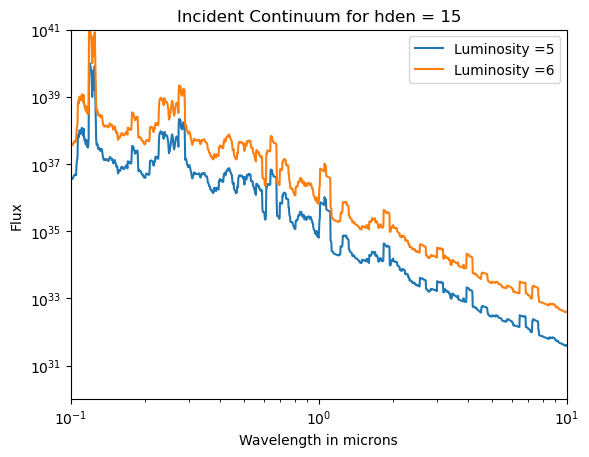

In [4]:
for h in range(5, 16):

    plt.figure()

    for L in range(5, 7):

        cont = data[h][L]

        energy = cont["#Cont  nu"].to_numpy()
        flux = cont["incident"].to_numpy()

        plt.loglog(energy, flux, label=f"Luminosity ={L}")

    plt.xlabel("Wavelength in microns")
    plt.ylabel("Flux")
    plt.title(f"Incident Continuum for hden = {h}")
    plt.legend()
    plt.xlim(1e-1, 1e1)
    plt.ylim(1e30,1e41)

    plt.show()

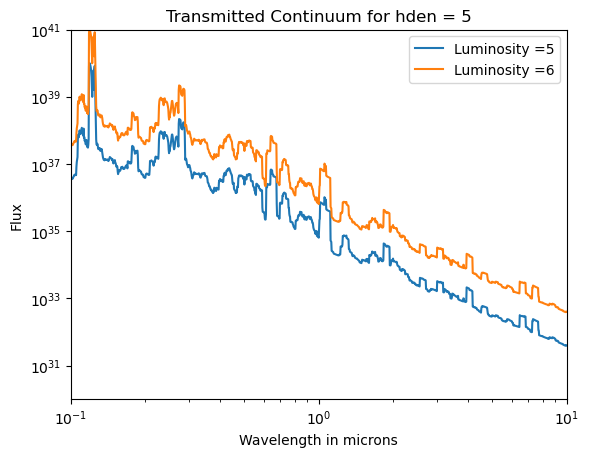

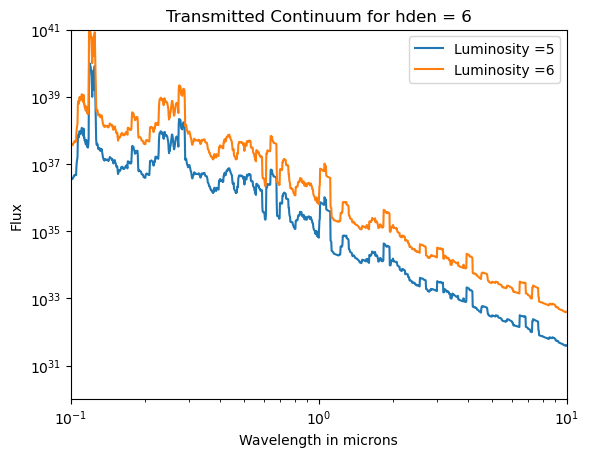

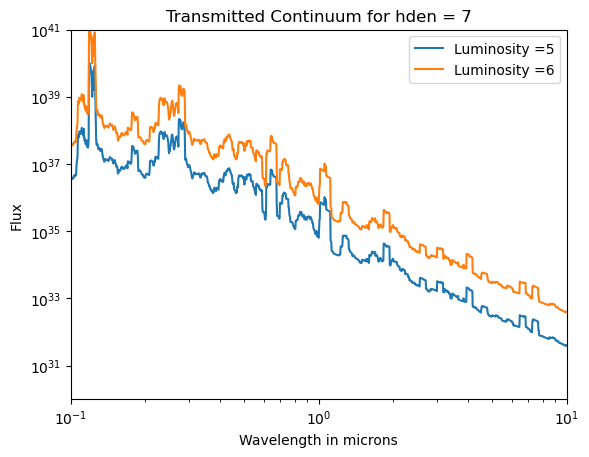

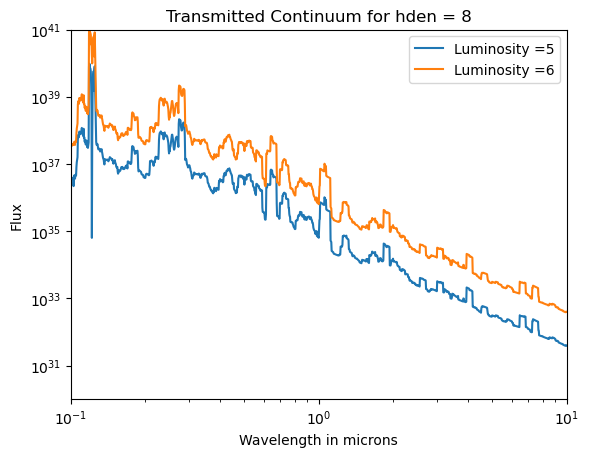

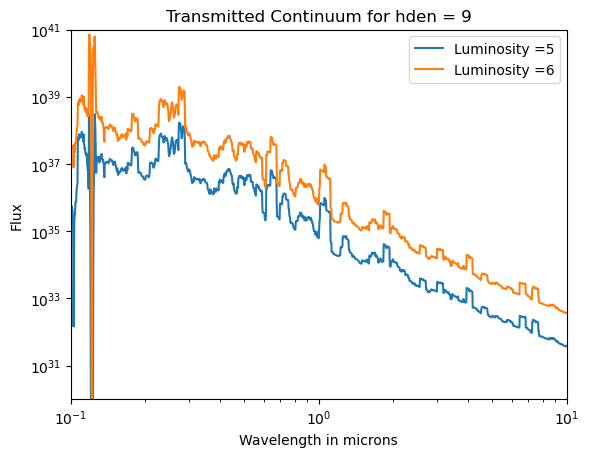

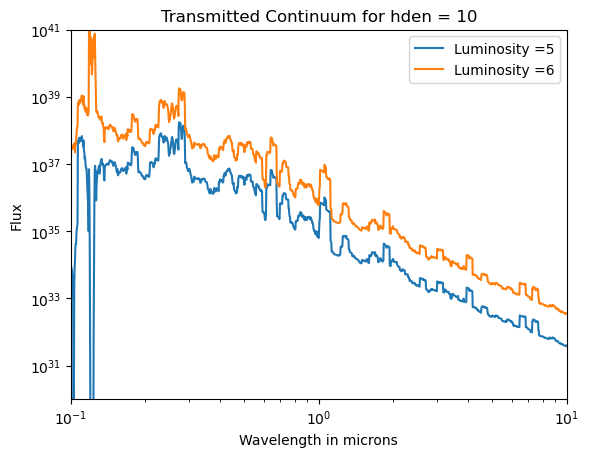

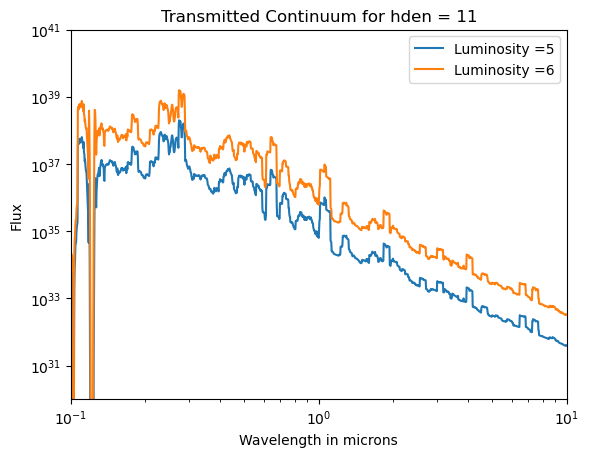

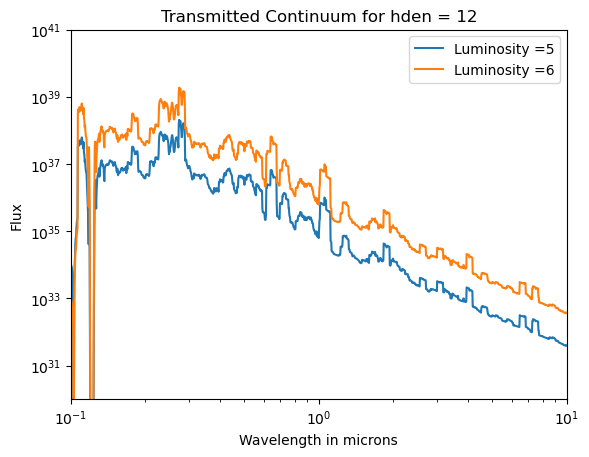

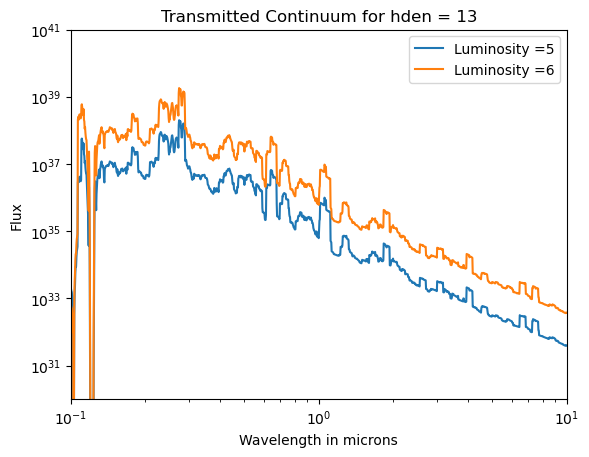

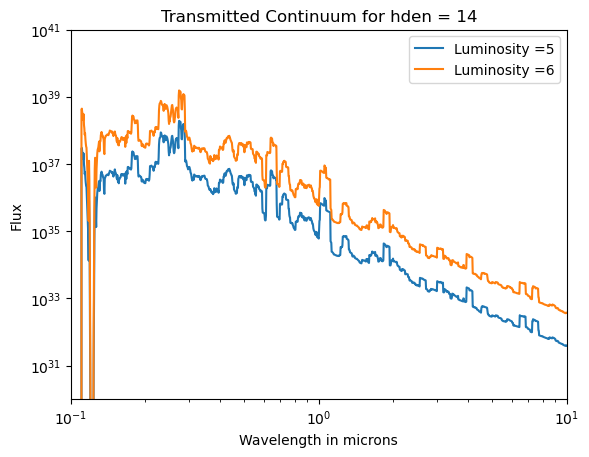

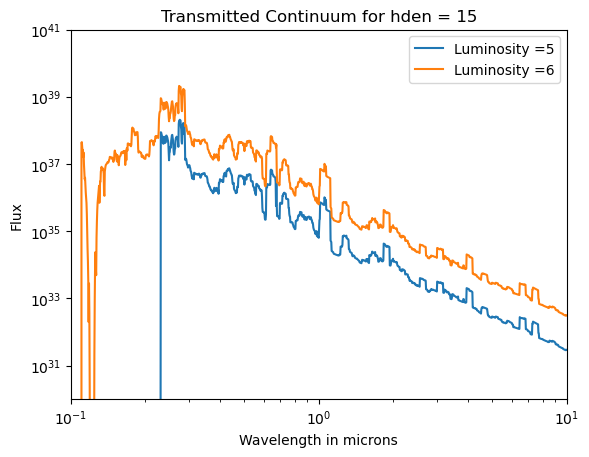

In [5]:
for h in range(5, 16):

    plt.figure()

    for L in range(5, 7):

        cont = data[h][L]

        energy = cont["#Cont  nu"].to_numpy()
        flux = cont["trans"].to_numpy()

        plt.loglog(energy, flux, label=f"Luminosity ={L}")

    plt.xlabel("Wavelength in microns")
    plt.ylabel("Flux")
    plt.title(f"Transmitted Continuum for hden = {h}")
    plt.legend()
    plt.xlim(1e-1, 1e1)
    plt.ylim(1e30,1e41)

    plt.show()

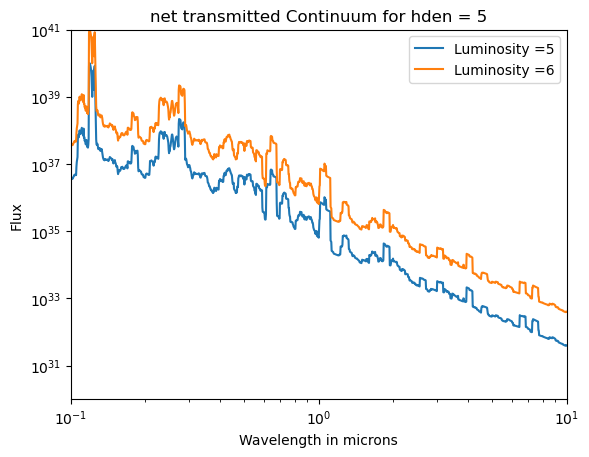

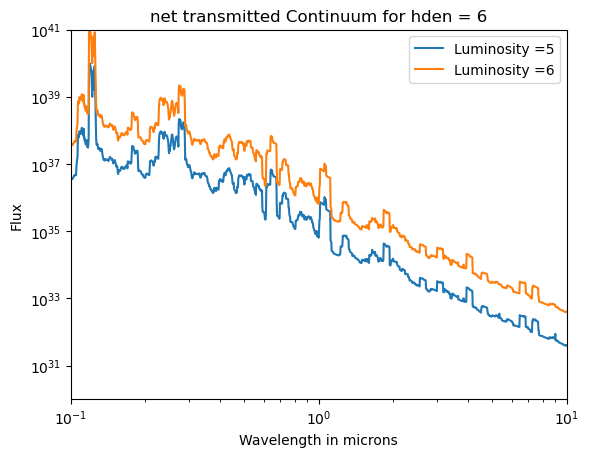

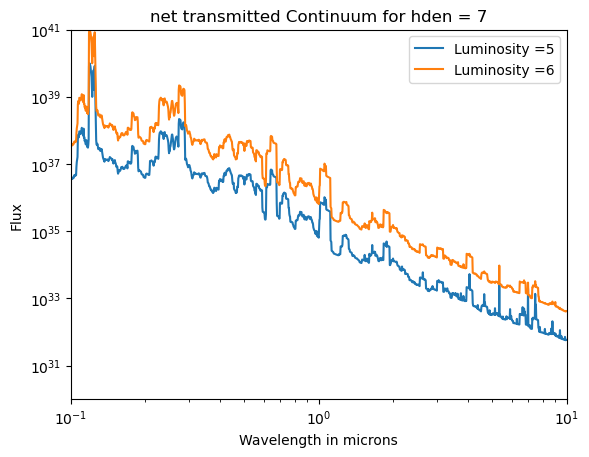

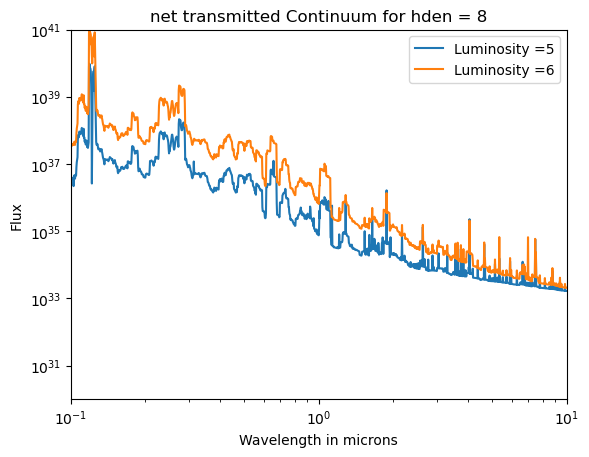

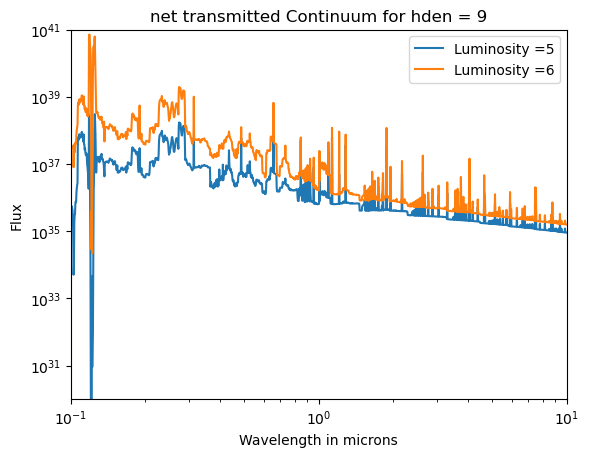

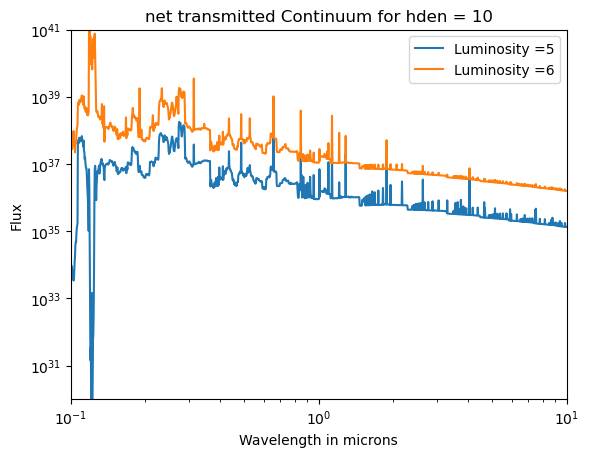

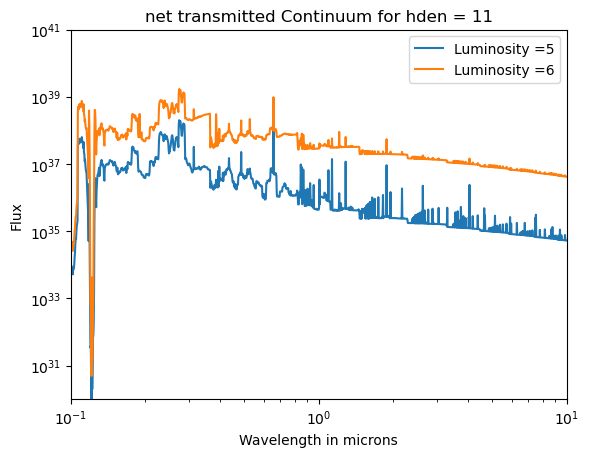

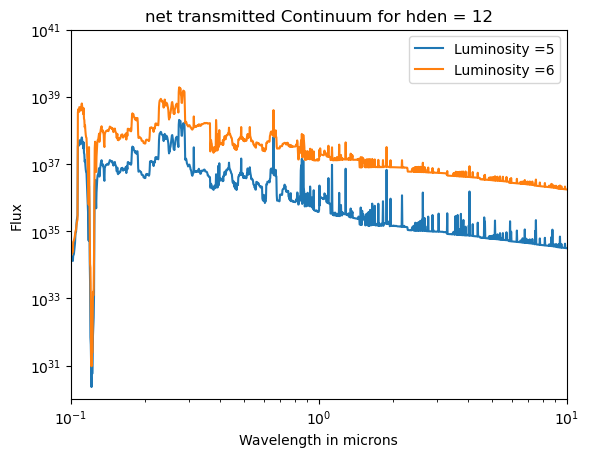

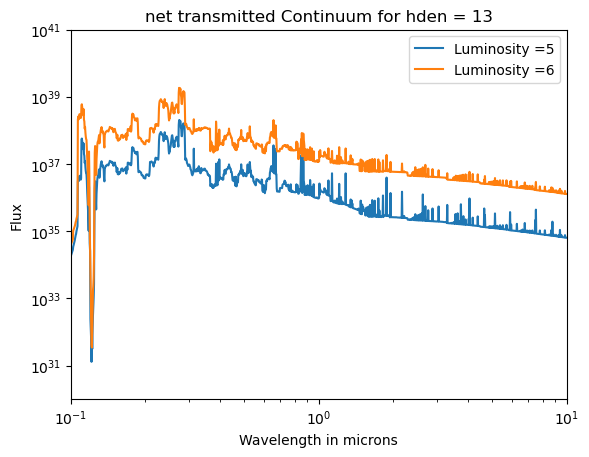

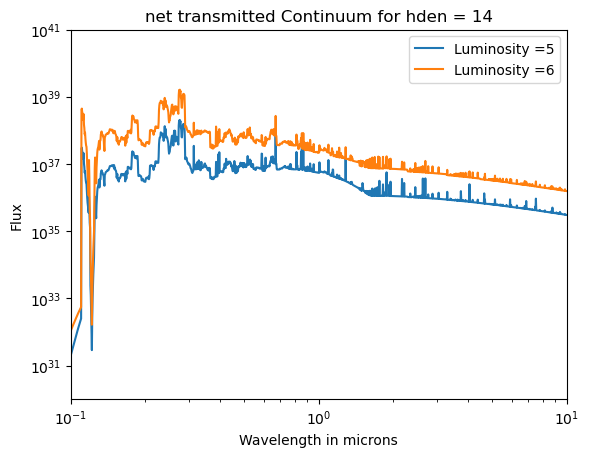

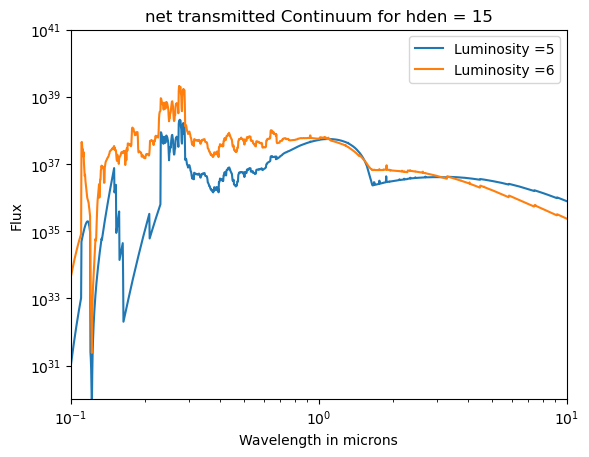

In [6]:
for h in range(5, 16):

    plt.figure()

    for L in range(5, 7):

        cont = data[h][L]

        energy = cont["#Cont  nu"].to_numpy()
        flux = cont["net trans"].to_numpy()

        plt.loglog(energy, flux, label=f"Luminosity ={L}")

    plt.xlabel("Wavelength in microns")
    plt.ylabel("Flux")
    plt.title(f"net transmitted Continuum for hden = {h}")
    plt.legend()
    plt.xlim(1e-1, 1e1)
    plt.ylim(1e30,1e41)

    plt.show()

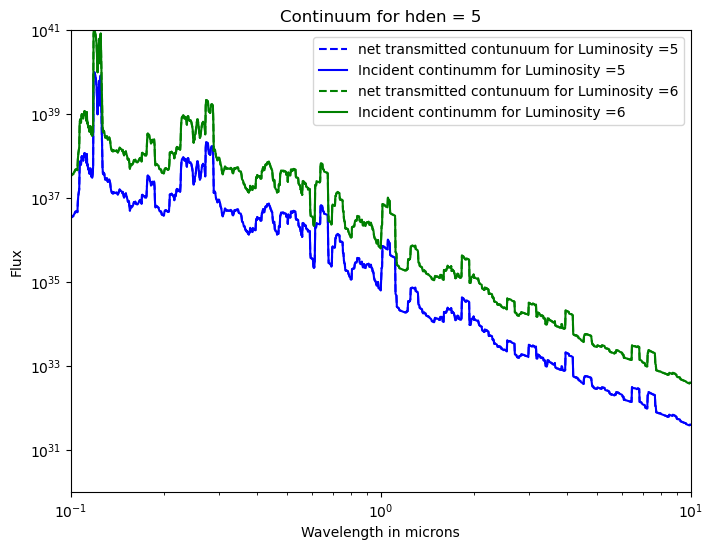

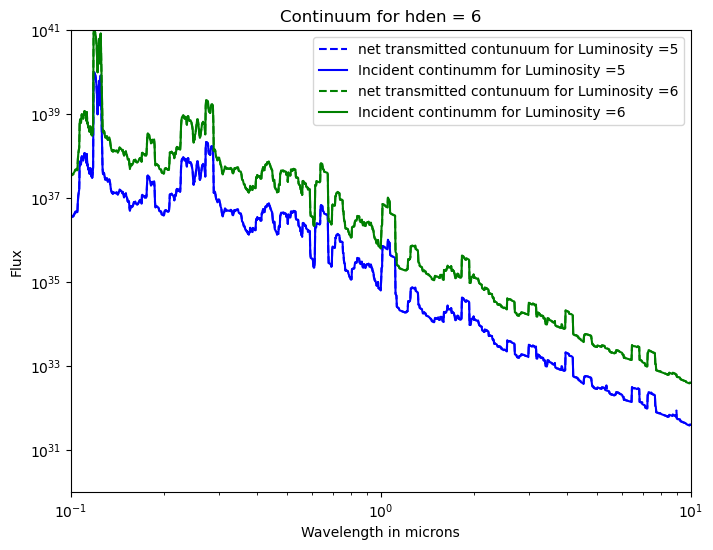

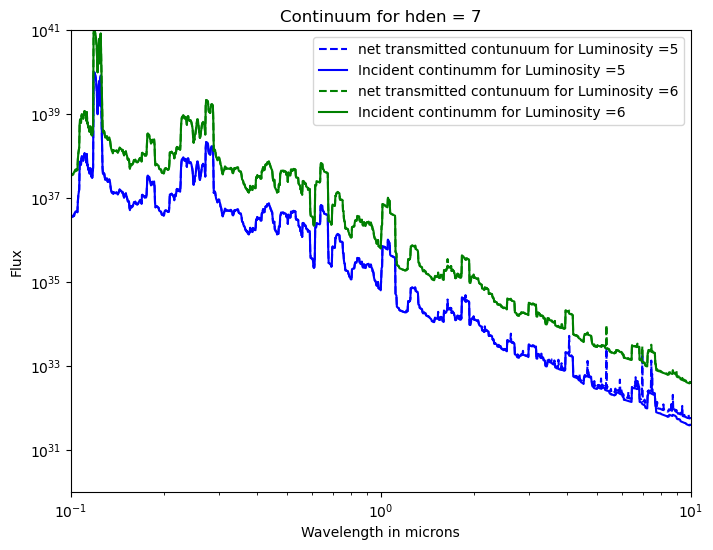

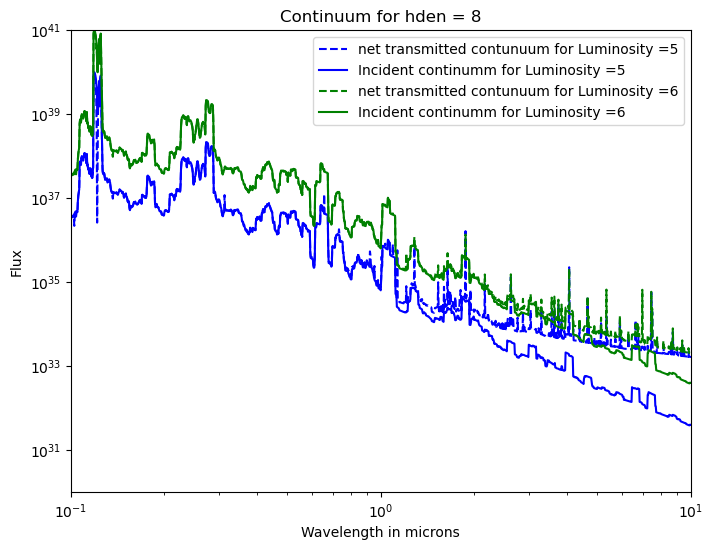

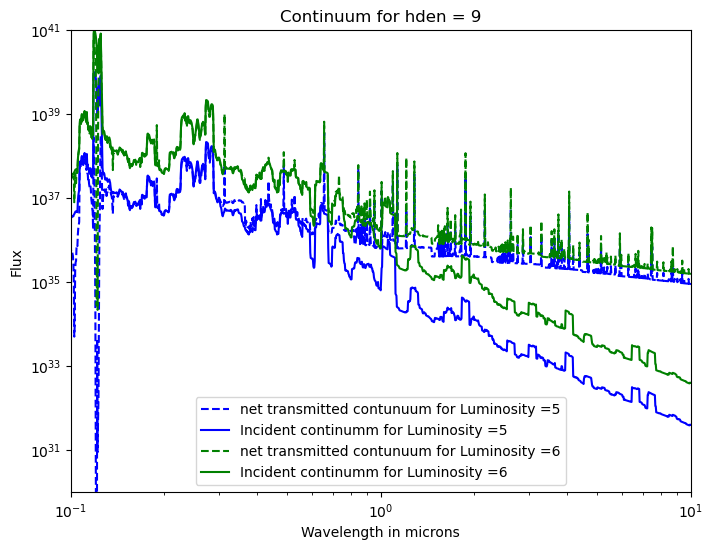

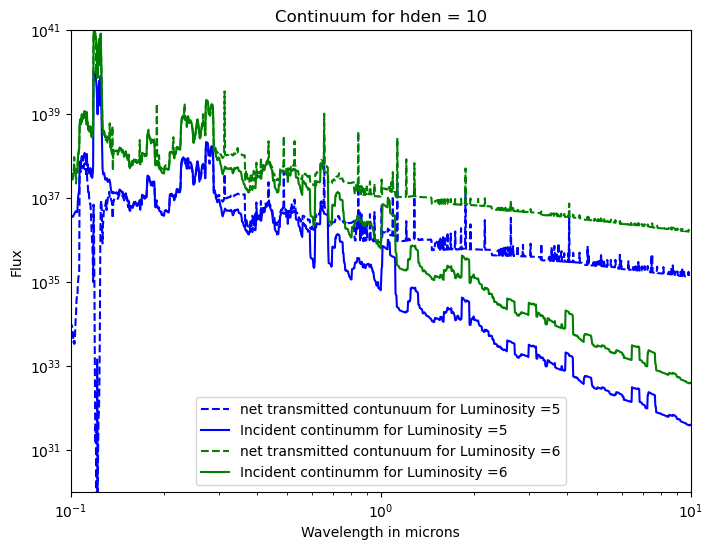

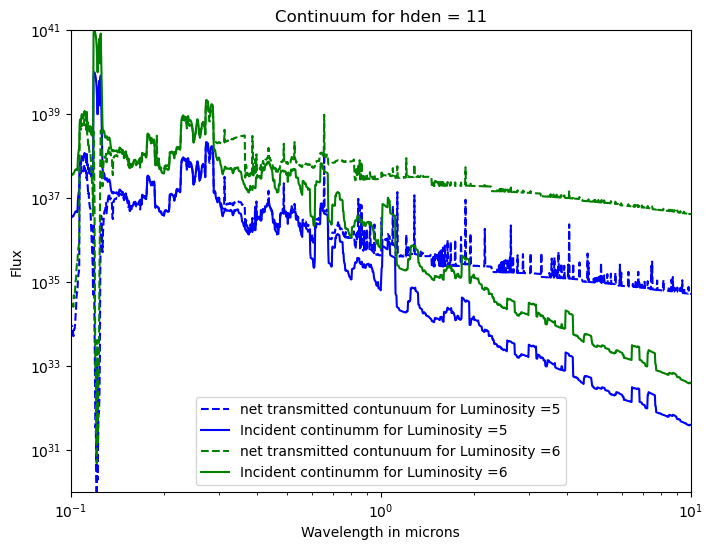

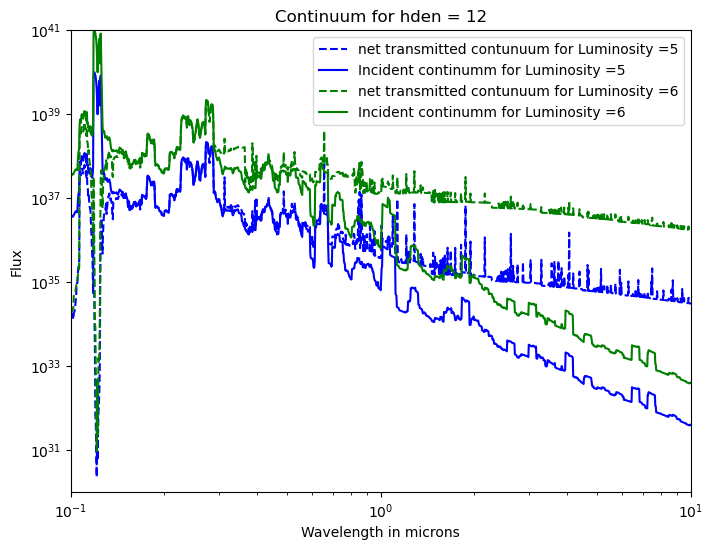

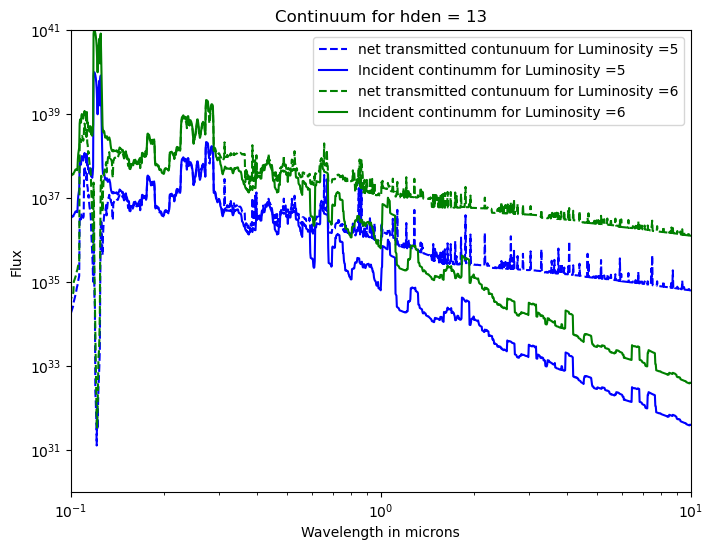

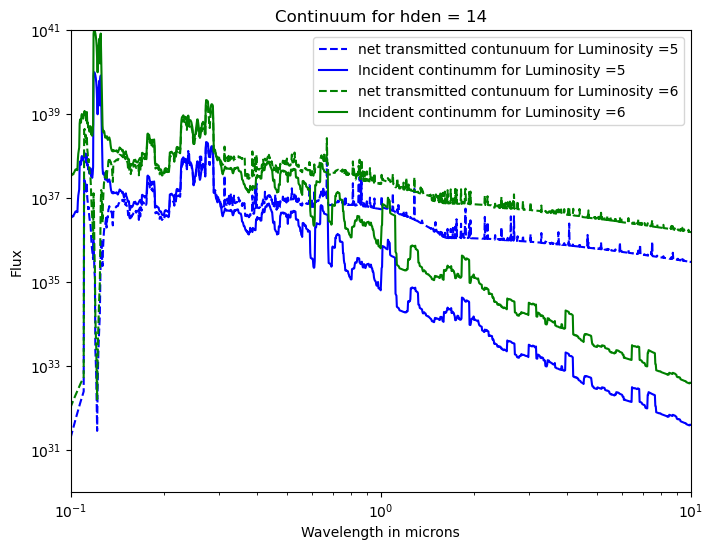

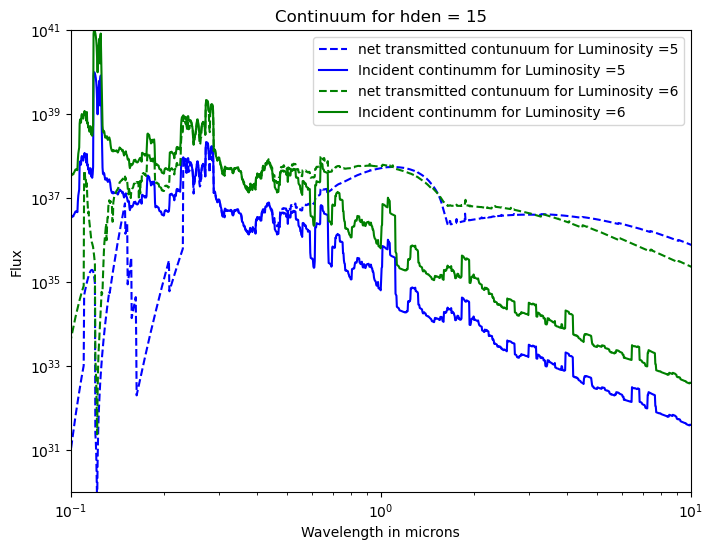

In [10]:
color = ["blue", "green"]
for h in range(5, 16):

    plt.figure(figsize=(8, 6))

    for L in range(5, 7):

        cont = data[h][L]

        energy = cont["#Cont  nu"].to_numpy()
        net_trans = cont["net trans"].to_numpy()
        incident = cont["incident"].to_numpy()
        plt.loglog(energy, net_trans,color = color[L - 5], linestyle = "--", label=f"net transmitted contunuum for Luminosity ={L}")
        plt.loglog(energy, incident,color = color[L - 5], label=f"Incident continumm for Luminosity ={L}")

    plt.xlabel("Wavelength in microns")
    plt.ylabel("Flux")
    plt.title(f"Continuum for hden = {h}")
    plt.legend()
    plt.xlim(1e-1, 1e1)
    plt.ylim(1e30,1e41)
    filename = f"incident_continuum_hden_{h}.png"

    plt.show()

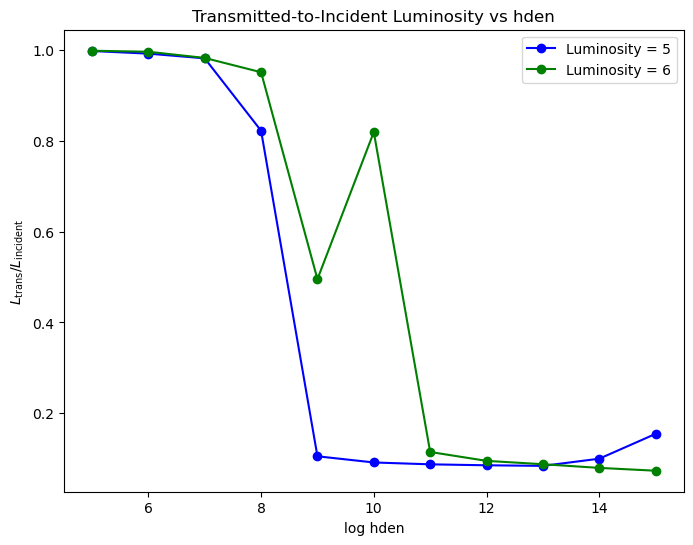

In [19]:
color = ["blue", "green"]

plt.figure(figsize=(8,6))

hden_values = list(range(5, 16))
for L in range(5, 7):

    ratio_vs_hden = []

    for h in hden_values:

        cont = data[h][L]

        x = cont["#Cont  nu"].to_numpy()
        net_trans = cont["net trans"].to_numpy()/x
        incident = cont["incident"].to_numpy()/x

        trans_lum = np.trapezoid(net_trans, x)
        inc_lum = np.trapezoid(incident, x)

        ratio_vs_hden.append(trans_lum / inc_lum)

    plt.plot(hden_values, ratio_vs_hden,marker='o',color=color[L-5],label=f'Luminosity = {L}')

plt.xlabel("log hden")
plt.ylabel(r"$L_{\rm trans}/L_{\rm incident}$")
plt.title("Transmitted-to-Incident Luminosity vs hden")
plt.legend()

plt.show()